# 5. Real-time Inference

Load the **best model** saved by notebook 4 from `models/best_model/` and run it on:
- A single test video (quick smoke test)
- A custom video file path
- A webcam stream (live)

Works with **both YOLO and MediaPipe** backends — the backend is read from `best_model_info.json`.

> For full batch processing of all videos, use **notebook 6 (6.batch_pipeline.ipynb)** instead.


In [7]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'matplotlib', 'tqdm']:
    install(pkg)
print('Dependencies ready.')


Dependencies ready.


In [8]:
import cv2, json, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import clear_output, display
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT           = Path('..').resolve()
PD_DIR         = ROOT / 'person_detector'
BEST_MODEL_DIR = PD_DIR / 'models' / 'best_model'
INFO_PATH      = BEST_MODEL_DIR / 'best_model_info.json'

if not INFO_PATH.exists():
    raise FileNotFoundError(
        f'{INFO_PATH} not found.\n'
        'Run notebook 4 (4.model_evaluation.ipynb) first.'
    )

info        = json.loads(INFO_PATH.read_text())
MODEL_ID    = info['model_id']
CONF_THRESH = info.get('conf_thresh', 0.30)
PERSON_CLS  = 0

print(f'Model ID    : {MODEL_ID}')
print(f'F1          : {info.get("f1", "?")}   IoU: {info.get("avg_iou", "?")}')
print(f'Conf thresh : {CONF_THRESH}')

# ── Load YOLO model once ──────────────────────────────────────────────────────
MODEL = YOLO(str(BEST_MODEL_DIR / 'best_model.pt'))
print(f'Loaded YOLO from {BEST_MODEL_DIR / "best_model.pt"}')

# ── Data directories ──────────────────────────────────────────────────────────
DATA_DIR    = ROOT / 'data'
sample_vids = (sorted((DATA_DIR / 'correct_form').glob('*.mp4')) +
               sorted((DATA_DIR / 'wrong_form').glob('*.mp4')))
OUTPUT_DIR  = PD_DIR / 'inference_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'\nVideos found: {len(sample_vids)}')


Model ID    : yolo11m.pt
F1          : 0.9945   IoU: 0.9933
Conf thresh : 0.3
Loaded YOLO from /Users/haleytran/Downloads/pushup_judge/person_detector/models/best_model/best_model.pt

Videos found: 152


## 5.1 Core Inference Functions

In [9]:
COLOR_CLOSEST = (0, 255, 0)     # green
COLOR_OTHER   = (100, 100, 255) # blue
COLOR_TEXT    = (255, 255, 255) # white


def infer_frame(frame_bgr):
    """
    Run one frame through the YOLO model.
    Returns (annotated_bgr, closest_box [x1,y1,x2,y2] or None, n_persons, infer_ms).
    """
    vis  = frame_bgr.copy()
    t0   = time.perf_counter()

    res   = MODEL.predict(frame_bgr, classes=[PERSON_CLS],
                          conf=CONF_THRESH, verbose=False)[0]
    boxes = res.boxes.xyxy.tolist() if (res.boxes is not None and len(res.boxes) > 0) else []
    confs = res.boxes.conf.tolist() if boxes else []
    areas = [(b[2]-b[0]) * (b[3]-b[1]) for b in boxes]
    ci    = int(np.argmax(areas)) if areas else -1

    for i, (box, cf) in enumerate(zip(boxes, confs)):
        x1, y1, x2, y2 = map(int, box)
        is_c  = (i == ci)
        color = COLOR_CLOSEST if is_c else COLOR_OTHER
        thick = 3 if is_c else 1
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thick)
        lbl = f'CLOSEST {cf:.2f}' if is_c else f'#{i+1} {cf:.2f}'
        (lw, lh), bl = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        ly = max(y1 - 5, lh + 5)
        bg = (0, 160, 0) if is_c else (60, 60, 160)
        cv2.rectangle(vis, (x1, ly-lh-bl), (x1+lw, ly), bg, -1)
        cv2.putText(vis, lbl, (x1, ly-bl), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_TEXT, 2)

    closest = boxes[ci] if ci >= 0 else None
    n_p     = len(boxes)
    ms      = (time.perf_counter() - t0) * 1000
    cv2.putText(vis, f'FPS:{1000/ms:.0f}  n:{n_p}', (8, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, COLOR_TEXT, 2, cv2.LINE_AA)
    return vis, closest, n_p, ms


def run_on_video(video_path, output_path=None, display_inline=True, max_frames=300):
    """Run inference on a video file. Returns stats dict."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open: {video_path}')

    fps_v = cap.get(cv2.CAP_PROP_FPS) or 30
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if output_path:
        writer = cv2.VideoWriter(str(output_path),
                                 cv2.VideoWriter_fourcc(*'mp4v'), fps_v, (W, H))

    times = []; n_frames = 0; n_detected = 0
    if display_inline:
        plt.figure(figsize=(10, 6))

    with tqdm(total=max_frames, desc='Inferring') as pbar:
        while n_frames < max_frames:
            ret, frame = cap.read()
            if not ret: break
            ann, closest, n_p, ms = infer_frame(frame)
            if closest: n_detected += 1
            times.append(ms)
            if writer: writer.write(ann)
            if display_inline and n_frames % 5 == 0:
                clear_output(wait=True)
                plt.clf()
                plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.title(f'Frame {n_frames} | {1000/ms:.1f} FPS', fontsize=12)
                plt.tight_layout()
                plt.pause(0.001)
                display(plt.gcf())
            n_frames += 1
            pbar.update(1)

    cap.release()
    if writer:
        writer.release()
        print(f'Saved → {output_path}')

    return {
        'total_frames'   : n_frames,
        'frames_detected': n_detected,
        'detection_rate' : round(n_detected / n_frames, 4) if n_frames else 0,
        'avg_infer_ms'   : round(float(np.mean(times)), 2),
        'avg_fps'        : round(1000 / float(np.mean(times)), 2),
    }


print('Inference functions ready.')


Inference functions ready.


## 5.2 Quick Test — First Video in Dataset

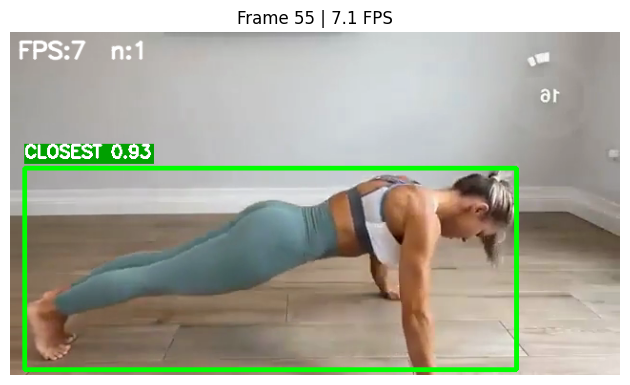

<Figure size 640x480 with 0 Axes>

Inferring: 100%|██████████| 60/60 [00:09<00:00,  6.01it/s]

Saved → /Users/haleytran/Downloads/pushup_judge/person_detector/inference_output/annotated_Copy of push up 1.mp4

=== Inference Stats ===
  total_frames        : 60
  frames_detected     : 60
  detection_rate      : 1.0
  avg_infer_ms        : 151.74
  avg_fps             : 6.59


<Figure size 640x480 with 0 Axes>

In [10]:
if not sample_vids:
    print('No videos found — check your data/ directory.')
else:
    sample_vid = sample_vids[0]
    out_vid    = OUTPUT_DIR / f'annotated_{sample_vid.name}'
    print(f'Running on: {sample_vid.name}')

    stats = run_on_video(
        video_path     = str(sample_vid),
        output_path    = str(out_vid),
        display_inline = True,
        max_frames     = 60,
    )

    print('\n=== Inference Stats ===')
    for k, v in stats.items():
        print(f'  {k:20s}: {v}')


## 5.3 Frame-by-Frame Static Gallery

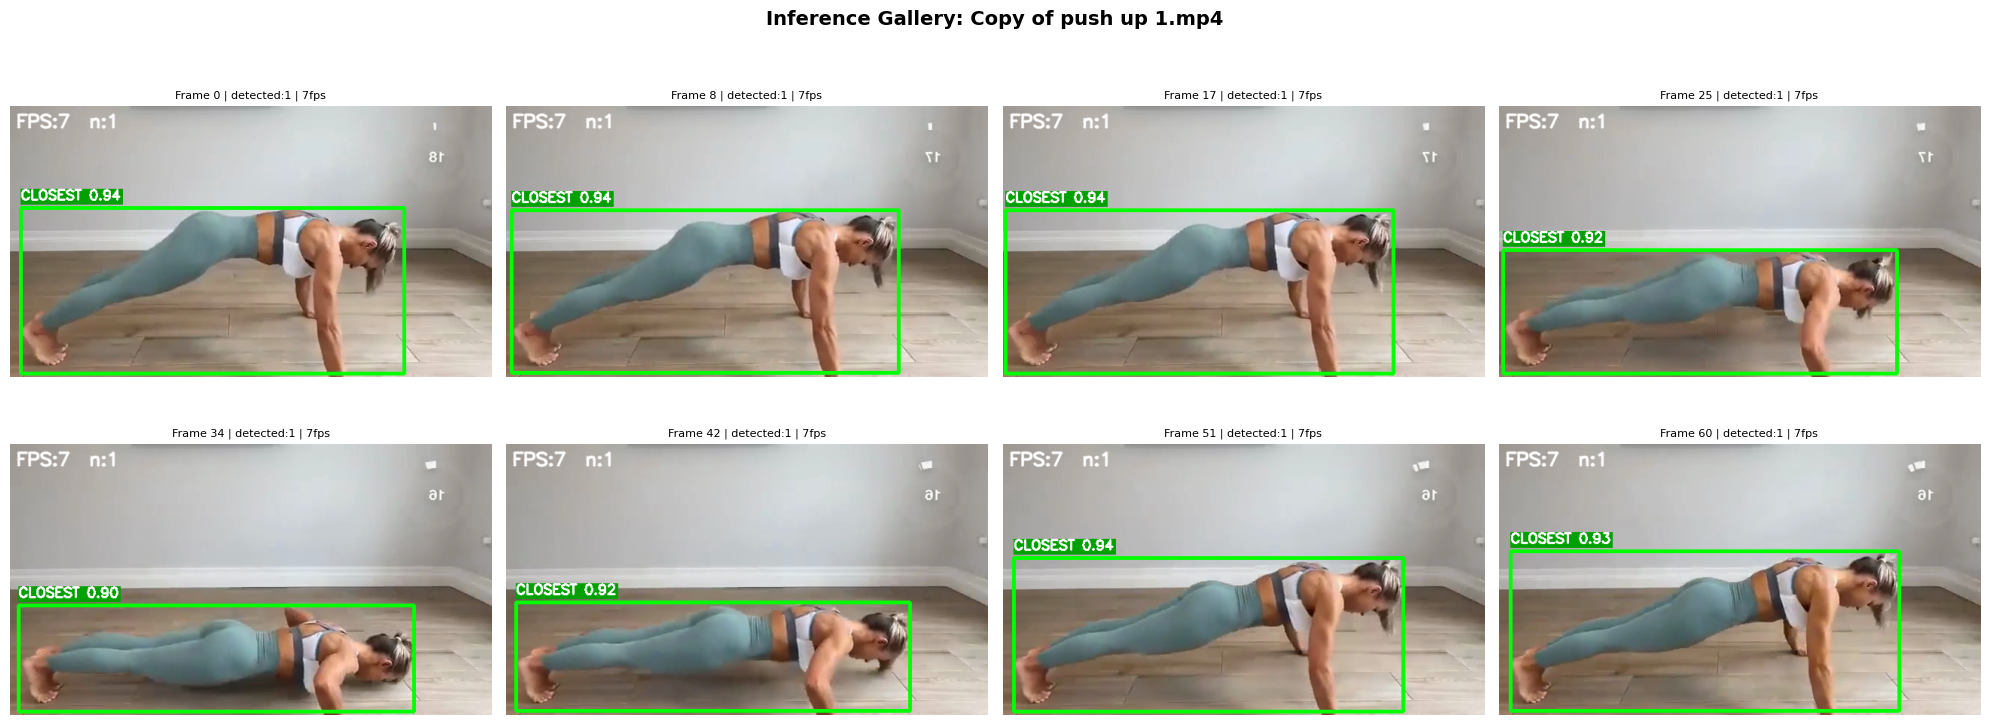

In [11]:
def show_gallery(video_path, n_frames=8):
    """Extract n evenly-spaced frames and display annotated results in a grid."""
    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs  = np.linspace(0, total - 1, n_frames, dtype=int)

    cols = 4
    rows = (n_frames + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    fig.suptitle(f'Inference Gallery: {Path(video_path).name}',
                 fontsize=14, fontweight='bold')
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes, idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            ax.axis('off'); continue
        ann, closest, n_p, ms = infer_frame(frame)
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {idx} | detected:{n_p} | {1000/ms:.0f}fps', fontsize=8)
        ax.axis('off')

    for ax in axes[n_frames:]:
        ax.axis('off')

    cap.release()
    plt.tight_layout()
    plt.show()


if sample_vids:
    show_gallery(str(sample_vids[0]), n_frames=8)


## 5.5 Run on a Custom Video

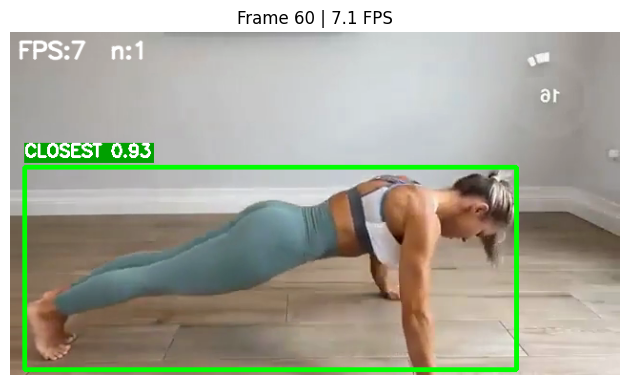

<Figure size 640x480 with 0 Axes>

Inferring:  20%|██        | 61/300 [00:09<00:38,  6.28it/s]

Saved → /Users/haleytran/Downloads/pushup_judge/person_detector/inference_output/custom_output.mp4

=== Stats ===
  total_frames        : 61
  frames_detected     : 61
  detection_rate      : 1.0
  avg_infer_ms        : 144.68
  avg_fps             : 6.91


<Figure size 640x480 with 0 Axes>

In [12]:
# ── Change this path to test your own video ──────────────────────────────────
CUSTOM_VIDEO = str(sample_vids[0]) if sample_vids else '/path/to/your_video.mp4'
SAVE_OUTPUT  = str(OUTPUT_DIR / 'custom_output.mp4')

print(f'Processing: {Path(CUSTOM_VIDEO).name}')

stats = run_on_video(
    video_path     = CUSTOM_VIDEO,
    output_path    = SAVE_OUTPUT,
    display_inline = True,
    max_frames     = 300,
)

print('\n=== Stats ===')
for k, v in stats.items():
    print(f'  {k:20s}: {v}')


## 5.6 Webcam Live Inference (Optional)
Uncomment and run the cell below to use your webcam.  
Press `q` in the OpenCV window to quit.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# WEBCAM INFERENCE — uncomment to use
# Press 'q' in the OpenCV window to quit.
# ─────────────────────────────────────────────────────────────────────────────
# cap = cv2.VideoCapture(0)
# while True:
#     ret, frame = cap.read()
#     if not ret: break
#     ann, closest, n_p, ms = infer_frame(frame)
#     cv2.imshow('Person Detector (q=quit)', ann)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break
# cap.release()
# cv2.destroyAllWindows()
print('Webcam cell is commented out. Uncomment to use.')


Webcam cell is commented out. Uncomment to use.
